# **Random Imputers**

we select a number among our data for imputing

Benefit:- easy to apply and data ka distribution bach jata h

ye ham linear regression me jata tar use krte h


coveriance disturbe ho jata h
and memory khata h jata

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
df=pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [ ]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
df.isnull().mean()

,0
Survived,0.000000
Age,0.198653
Fare,0.000000


In [ ]:
x=df.drop('Survived',axis=1)
y=df['Survived']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [ ]:
x_train['Age_imputed']=x_train['Age']
x_test['Age_imputed']=x_test['Age']

In [ ]:
x_train['Age_imputed'][x_train['Age_imputed'].isnull()]=x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values
x_test['Age_imputed'][x_test['Age_imputed'].isnull()]=x_test['Age'].dropna().sample(x_test['Age'].isnull().sum()).values

/tmp/ipython-input-2031519514.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  x_train['Age_imputed'][x_train['Age_imputed'].isnull()]=x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values
/tmp/ipython-input-2031519514.py:2

In [ ]:
x_train.isnull().sum()

,0
Age,148
Fare,0
Age_imputed,0


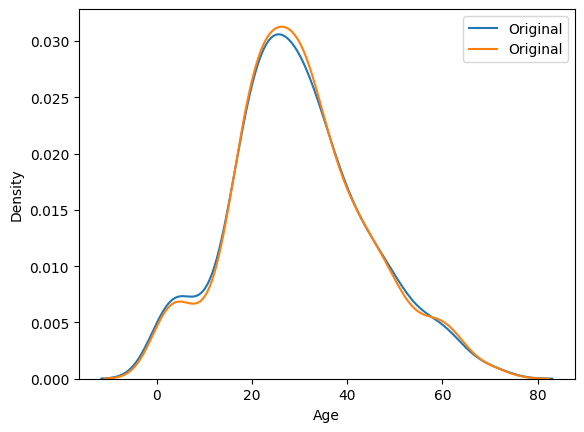

In [ ]:
sns.kdeplot(x_train['Age'],label='Original')
sns.kdeplot(x_train['Age_imputed'],label='Original')
plt.legend()
plt.show()

In [ ]:
print("original variable variance: ",x_train['Age'].var())
print("imputed variable variance: ",x_train['Age_imputed'].var())

original variable variance:  204.3495133904614
imputed variable variance:  200.3185642503831


In [ ]:
x_train.cov()

,Age,Fare,Age_imputed
Age,204.349513,71.512440,204.349513
Fare,71.512440,2368.246832,54.207414
Age_imputed,204.349513,54.207414,200.318564


<Axes: >

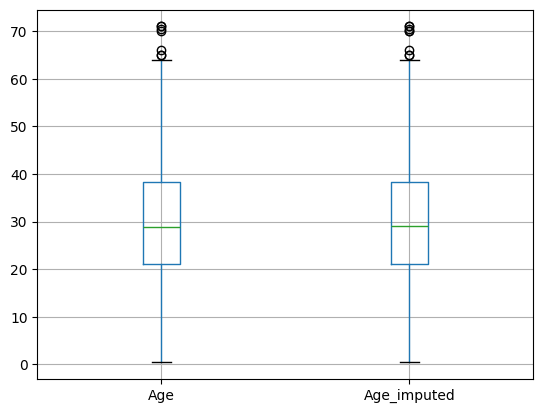

In [ ]:
x_train[['Age','Age_imputed']].boxplot()

In [ ]:
# sample_value=x_train['Age'].dropna().sample(1,random_state=int(observation['Fare']))
# it is for always insuring that our model generates same value all the time

In [ ]:
data=pd.read_csv("/content/house-train.csv",usecols=['GarageQual','FireplaceQu','SalePrice'])

In [ ]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [ ]:
data.isnull().mean()

,0
FireplaceQu,0.472603
GarageQual,0.055479
SalePrice,0.000000


In [ ]:
x=data
y=data['SalePrice']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [ ]:
x_train['GarageQual_imputed']=x_train['GarageQual']
x_test['GarageQual_imputed']=x_test['GarageQual']

x_train['FireplaceQu_imputed']=x_train['FireplaceQu']
x_test['FireplaceQu_imputed']=x_test['FireplaceQu']

In [ ]:
x_train['GarageQual_imputed'][x_train['GarageQual_imputed'].isnull()]=x_train['GarageQual'].dropna().sample(x_train['GarageQual'].isnull().sum()).values
x_test['GarageQual_imputed'][x_test['GarageQual_imputed'].isnull()]=x_test['GarageQual'].dropna().sample(x_test['GarageQual'].isnull().sum()).values

x_train['FireplaceQu_imputed'][x_train['FireplaceQu_imputed'].isnull()]=x_train['FireplaceQu'].dropna().sample(x_train['FireplaceQu'].isnull().sum()).values
x_test['FireplaceQu_imputed'][x_test['FireplaceQu_imputed'].isnull()]=x_test['FireplaceQu'].dropna().sample(x_test['FireplaceQu'].isnull().sum()).values

/tmp/ipython-input-3674334412.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  x_train['GarageQual_imputed'][x_train['GarageQual_imputed'].isnull()]=x_train['GarageQual'].dropna().sample(x_train['GarageQual'].isnull().sum()).values
/tmp/i

In [ ]:
temp=pd.concat(
    [
        x_train['GarageQual'].value_counts()/len(x_train['GarageQual'].dropna()),
        x_train['GarageQual_imputed'].value_counts()/len(x_train)
    ],
    axis=1
)
temp.colums=['original','imputed']

/tmp/ipython-input-3013888060.py:8: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  temp.colums=['original','imputed']


In [ ]:
temp

,count,count
TA,0.951043,0.952911
Fa,0.037171,0.035103
Gd,0.009973,0.010274
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [ ]:
temp=pd.concat(
    [
        x_train['FireplaceQu'].value_counts()/len(x_train['FireplaceQu'].dropna()),
        x_train['FireplaceQu_imputed'].value_counts()/len(x_train)
    ],
    axis=1
)
temp.colums=['original','imputed']

/tmp/ipython-input-3454434841.py:8: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  temp.colums=['original','imputed']


In [ ]:
temp

,count,count
Gd,0.494272,0.494007
TA,0.412439,0.412671
Fa,0.040917,0.041096
Po,0.027823,0.028253
Ex,0.024550,0.023973


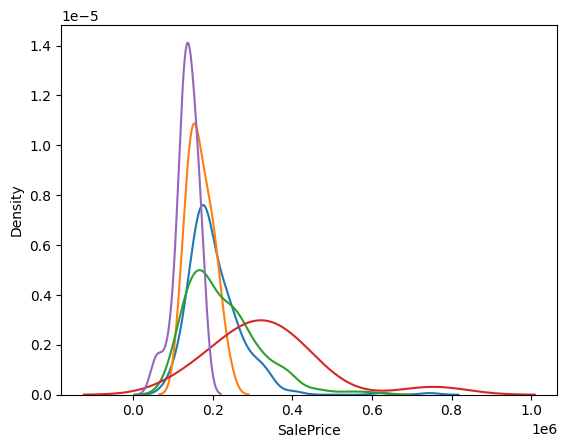

In [ ]:
for category in x_train['FireplaceQu'].dropna().unique():
  sns.kdeplot(x_train[x_train['FireplaceQu']== category]['SalePrice'],label=category)
plt.show()

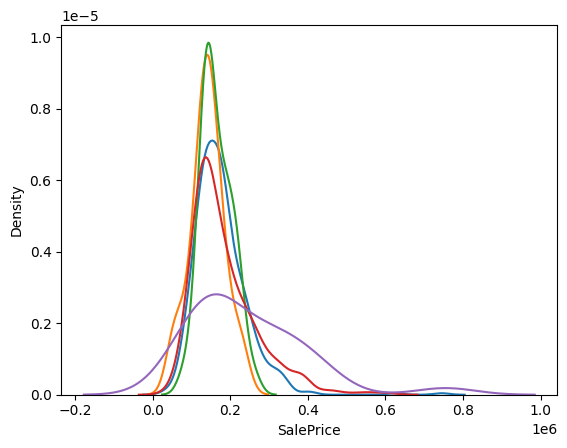

In [ ]:
for category in x_train['FireplaceQu_imputed'].dropna().unique():
  sns.kdeplot(x_train[x_train['FireplaceQu_imputed']== category]['SalePrice'],label=category)
plt.show()

# **Misssing Inficator**

Missing indicator me ham ek naya column banate h jisme haa ye batate hai ki konsa row me missing value h

In [ ]:
df=pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [ ]:
x=df.drop('Survived',axis=1)
y=df['Survived']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [ ]:
from sklearn.impute import MissingIndicator,SimpleImputer

In [ ]:
si=SimpleImputer()
x_train_trf=si.fit_transform(x_train)
x_test_trf=si.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

clf=LogisticRegression()

clf.fit(x_train_trf,y_train)

y_pred=clf.predict(x_test_trf)

from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.6145251396648045

In [ ]:
mi=MissingIndicator()

mi.fit(x_train)

MissingIndicator()

In [ ]:
x_train_missing=mi.transform(x_train)

In [ ]:
x_test_missing=mi.transform(x_test)

In [ ]:
x_train['Age_NA']=x_train_missing
x_test['Age_NA']=x_test_missing

In [ ]:
si=SimpleImputer()
x_train_trf2=si.fit_transform(x_train)
x_test_trf2=si.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

clf=LogisticRegression()

clf.fit(x_train_trf2,y_train)

y_pred=clf.predict(x_test_trf2)

from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.6312849162011173

Simple Imputer me ek attribute hota h add_indicator kr ke agar isko ham true kr de to wo apane aap ek table bana ke deta h

Automatically indicators selection by gridSearchCv lec 38 me dekho code